# Programa Ingenias+ Data Science

---

# PRE-ENTREGA 2  

**Grupo 5**

Belen Massuco -

---


**Tema y dataset seleccionado**

Este dataset ofrece una visión detallada, a nivel nacional, de los sistemas energéticos mundiales, reflejando la evolución del consumo de energía, la generación de electricidad, la combinación de combustibles y las emisiones a lo largo del tiempo. Abarca los combustibles fósiles, las energías renovables, la energía nuclear, la demanda y producción de electricidad, las importaciones y las emisiones de gases de efecto invernadero.

Fuente dataset: https://www.kaggle.com/datasets/bhavikjikadara/global-energy-electricity-and-emissions-data/data


**Exploración y transformación de datos con Pandas**

Comenzamos explorando la estructura general del dataset: contiene más de 20.000 registros y 130 features originales con información sobre las diferentes fuentes de energía a nivel país y regional. Debido a la extensión de las features se decidió que el estudio solo se concentraría en las mas relevantes reduciendo el dataset a aproximadamente 30 features.

Identificamos que las columnas tenian un tipo de dato correspondiente a su naturaleza, por lo que no fue necesario una transformación posterior por este tema.

Se hizo una evaluación de los datos faltantes y se decidió no eliminar ninguno ya que es de esperar que no existan registros en todos los años para las diferentes energías en cada país.


**Visualización inicial de datos**

A través de gráficos exploratorios buscamos identificar patrones y relaciones entre variables: heatmap de correlación, series temporales y gráficos de barra y líneas.




## Importar librerias y dataset

In [46]:
# Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Importación del dataset
df = pd.read_csv('/content/energy_data.csv')

## Exploración del dataset

In [48]:
# Mostrar primeras filas
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [49]:
# Mostrar cantidad de filas y features
ff = df.shape
print(f'El dataset contiene {ff[0]} filas y {ff[1]} features.')

El dataset contiene 23232 filas y 130 features.


In [50]:
# Ver tipos de datos
df.dtypes

,0
country,object
year,int64
iso_code,object
population,float64
gdp,float64
...,...
wind_elec_per_capita,float64
wind_electricity,float64
wind_energy_per_capita,float64
wind_share_elec,float64


In [51]:
# Mostrar nombres de las features
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

In [52]:
# Contar valores nulos y mostrar porcentaje
faltantes = pd.DataFrame({'Valores nulos': df.isnull().sum(), 'Porcentaje (%)': (df.isnull().sum() / len(df)) * 100})
faltantes.sort_values(by='Valores nulos', ascending=False)

,Valores nulos,Porcentaje (%)
biofuel_cons_change_pct,21162,91.089876
solar_cons_change_pct,20717,89.174415
nuclear_cons_change_pct,20653,88.898933
wind_cons_change_pct,20434,87.956267
other_renewables_cons_change_pct,19244,82.834022
...,...,...
oil_prod_change_twh,5503,23.687156
oil_production,5240,22.555096
population,4472,19.249311
year,0,0.000000


## Filtrado del dataset

Debido a la gran extensión de registros y features se decidió no tener en cuenta las regiones y solo concentrarnos en los datos de paises.
Además no se utilizarán la totalidad de las features, siendo las elegidas:
* [country, year, iso_code, population, gdp]
* [primary_energy_consumption, energy_per_capita, energy_per_gdp]
* [electricity_generation, electricity_demand, electricity_demand_per_capita]
* [coal_consumption, coal_electricity, coal_production]
* [oil_consumption, oil_electricity, oil_production]
* [gas_consumption, gas_electricity, gas_production]
* [renewables_consumption, renewables_electricity]
* [solar_consumption, solar_electricity]
* [wind_consumption, wind_electricity]
* [hydro_consumption, hydro_electricity]
* [nuclear_consumption, nuclear_electricity]
* [greenhouse_gas_emissions]

In [53]:
# Códigos ISO unicos correspondientes a cada país
df["iso_code"].dropna().unique()

array(['AFG', 'ALB', 'DZA', 'ASM', 'AGO', 'ATA', 'ATG', 'ARG', 'ARM',
       'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB', 'BLR',
       'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BIH', 'BWA', 'BRA',
       'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR', 'CAN', 'CPV',
       'CYM', 'CAF', 'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COG', 'COK',
       'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE', 'COD', 'DNK',
       'DJI', 'DMA', 'DOM', 'TLS', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI',
       'EST', 'SWZ', 'ETH', 'FLK', 'FRO', 'FJI', 'FIN', 'FRA', 'GUF',
       'PYF', 'GAB', 'GMB', 'GEO', 'DEU', 'GHA', 'GIB', 'GRC', 'GRL',
       'GRD', 'GLP', 'GUM', 'GTM', 'GIN', 'GNB', 'GUY', 'HTI', 'HND',
       'HKG', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ', 'IRL', 'ISR',
       'ITA', 'JAM', 'JPN', 'JOR', 'KAZ', 'KEN', 'KIR', 'KWT', 'KGZ',
       'LAO', 'LVA', 'LBN', 'LSO', 'LBR', 'LBY', 'LTU', 'LUX', 'MAC',
       'MDG', 'MWI', 'MYS', 'MDV', 'MLI', 'MLT', 'MTQ', 'MRT', 'MUS',
       'MEX', 'FSM',

In [54]:
# Registros que tienen código ISO
df["iso_code"].notna().sum()

np.int64(17134)

In [55]:
# Entidades que no tienen código ISO
df.loc[df["iso_code"].isna(), "country"].unique()

array(['ASEAN (Ember)', 'Africa', 'Africa (EI)', 'Africa (EIA)',
       'Africa (Ember)', 'Africa (Shift)', 'Asia', 'Asia (Ember)',
       'Asia Pacific (EI)', 'Asia and Oceania (EIA)',
       'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)',
       'CIS (EI)', 'Central America (EI)',
       'Central and South America (EIA)',
       'Central and South America (Shift)', 'Czechoslovakia',
       'EU (Ember)', 'EU28 (Shift)', 'East Germany',
       'Eastern Africa (EI)', 'Eastern Europe and Eurasia (EIA)',
       'Eurasia (EIA)', 'Eurasia (Shift)', 'Europe', 'Europe (EI)',
       'Europe (EIA)', 'Europe (Ember)', 'Europe (Shift)',
       'European Union (27)', 'G20 (Ember)', 'G7 (Ember)',
       'High-income countries', 'Kosovo',
       'Latin America and Caribbean (Ember)', 'Low-income countries',
       'Lower-middle-income countries', 'Middle Africa (EI)',
       'Middle East (EI)', 'Middle East (EIA)', 'Middle East (Ember)',
       'Middle East (Shift)', 'Non-OECD (EI)', 

In [56]:
con_iso = df[df["iso_code"].notna()]
sin_iso = df[df["iso_code"].isna()]

print("Entidades con ISO:", con_iso["country"].nunique())
print("Entidades sin ISO:", sin_iso["country"].nunique())

Entidades con ISO: 220
Entidades sin ISO: 94


In [57]:
print("\nRegistros sin código ISO a filtrar:")
print(sin_iso["country"].drop_duplicates().to_list())


Registros sin código ISO a filtrar:
['ASEAN (Ember)', 'Africa', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Asia', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (EIA)', 'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)', 'CIS (EI)', 'Central America (EI)', 'Central and South America (EIA)', 'Central and South America (Shift)', 'Czechoslovakia', 'EU (Ember)', 'EU28 (Shift)', 'East Germany', 'Eastern Africa (EI)', 'Eastern Europe and Eurasia (EIA)', 'Eurasia (EIA)', 'Eurasia (Shift)', 'Europe', 'Europe (EI)', 'Europe (EIA)', 'Europe (Ember)', 'Europe (Shift)', 'European Union (27)', 'G20 (Ember)', 'G7 (Ember)', 'High-income countries', 'Kosovo', 'Latin America and Caribbean (Ember)', 'Low-income countries', 'Lower-middle-income countries', 'Middle Africa (EI)', 'Middle East (EI)', 'Middle East (EIA)', 'Middle East (Ember)', 'Middle East (Shift)', 'Non-OECD (EI)', 'Non-OECD (EIA)', 'Non-OPEC (EI)', 'Non-OPEC (EIA)', 'North America', 'North Amer

In [58]:
# Se hace una copia del dataset previo al filtrado de registros y features
df_eda = df.copy()

In [59]:
# Se definen las columnas a conservar
columnas = [
    # Identificación y contexto
    "country",
    "year",
    "iso_code",
    "population",
    "gdp",

    # Energía total
    "primary_energy_consumption",
    "energy_per_capita",
    "energy_per_gdp",

    # Electricidad
    "electricity_generation",
    "electricity_demand",
    "electricity_demand_per_capita",

    # Carbón
    "coal_consumption",
    "coal_electricity",
    "coal_production",

    # Petróleo
    "oil_consumption",
    "oil_electricity",
    "oil_production",

    # Gas
    "gas_consumption",
    "gas_electricity",
    "gas_production",

    # Renovables
    "renewables_consumption",
    "renewables_electricity",

    # Solar
    "solar_consumption",
    "solar_electricity",

    # Eólica
    "wind_consumption",
    "wind_electricity",

    # Hidráulica
    "hydro_consumption",
    "hydro_electricity",

    # Nuclear
    "nuclear_consumption",
    "nuclear_electricity",

    # Emisiones
    "greenhouse_gas_emissions",
]

In [60]:
# Se crea el nuevo dataset con las columnas elegidas
df_eda = df.loc[df["iso_code"].notna(), columnas].copy()

In [61]:
# Mostrar cantidad de filas y features del nuevo dataset
ff = df_eda.shape
print(f'El dataset contiene {ff[0]} filas y {ff[1]} features.')

El dataset contiene 17134 filas y 31 features.


In [62]:
df_eda.dtypes

,0
country,object
year,int64
iso_code,object
population,float64
gdp,float64
primary_energy_consumption,float64
energy_per_capita,float64
energy_per_gdp,float64
electricity_generation,float64
electricity_demand,float64


In [63]:
df_eda.head()

,country,year,iso_code,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,electricity_generation,electricity_demand,...,renewables_electricity,solar_consumption,solar_electricity,wind_consumption,wind_electricity,hydro_consumption,hydro_electricity,nuclear_consumption,nuclear_electricity,greenhouse_gas_emissions
25,Afghanistan,1900,AFG,4707744.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,Afghanistan,1901,AFG,4751177.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Afghanistan,1902,AFG,4802500.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,Afghanistan,1903,AFG,4861833.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,Afghanistan,1904,AFG,4921891.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Se reinicia el índice
df_eda = df_eda.reset_index(drop=True)

## Datos faltantes

In [65]:
# Contar valores nulos y mostrar porcentaje (chequeo)
missing_data = pd.DataFrame({'Valores nulos': df_eda.isnull().sum(), 'Porcentaje (%)': (df_eda.isnull().sum() / len(df_eda)) * 100})
missing_data.sort_values(by='Valores nulos', ascending=False)

,Valores nulos,Porcentaje (%)
oil_consumption,12669,73.940703
coal_consumption,12669,73.940703
hydro_consumption,12669,73.940703
wind_consumption,12669,73.940703
solar_consumption,12669,73.940703
renewables_consumption,12669,73.940703
gas_consumption,12669,73.940703
greenhouse_gas_emissions,11984,69.942804
electricity_demand_per_capita,11619,67.812536
electricity_demand,11619,67.812536


In [66]:
# Ver filas sin datos
df_eda[df_eda.isna().any(axis=1)]

,country,year,iso_code,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,electricity_generation,electricity_demand,...,renewables_electricity,solar_consumption,solar_electricity,wind_consumption,wind_electricity,hydro_consumption,hydro_electricity,nuclear_consumption,nuclear_electricity,greenhouse_gas_emissions
0,Afghanistan,1900,AFG,4707744.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1901,AFG,4751177.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1902,AFG,4802500.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1903,AFG,4861833.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1904,AFG,4921891.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17129,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,33.585716,2163.068359,1.448990,6.71,8.69,...,3.93,NaN,0.02,NaN,0.0,NaN,3.81,0.0,0.0,2.49
17130,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,37.635838,2382.434326,1.497045,8.57,10.31,...,6.06,NaN,0.02,NaN,0.0,NaN,5.93,0.0,0.0,2.31
17131,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,58.379982,3633.067383,2.253915,8.94,10.85,...,6.02,NaN,0.03,NaN,0.0,NaN,5.88,0.0,0.0,2.66
17132,Zimbabwe,2023,ZWE,16340829.0,NaN,51.986076,3181.361084,NaN,8.31,10.21,...,5.61,NaN,0.03,NaN,0.0,NaN,5.46,0.0,0.0,2.48


In [67]:
# Ver que registros no tienen datos de variables energéticas
columnas_base = [
    "country",
    "year",
    "iso_code",
    "population",
    "gdp"
]

columnas_energia = df_eda.columns.difference(columnas_base)

In [68]:
filas_sin_energia = df_eda[
    df_eda[columnas_energia].isna().all(axis=1)
]
filas_sin_energia

,country,year,iso_code,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,electricity_generation,electricity_demand,...,renewables_electricity,solar_consumption,solar_electricity,wind_consumption,wind_electricity,hydro_consumption,hydro_electricity,nuclear_consumption,nuclear_electricity,greenhouse_gas_emissions


In [69]:
cantidad_sin_energia = df_eda[columnas_energia].isna().all(axis=1).sum()

porcentaje_sin_energia = (
    cantidad_sin_energia / len(df_eda) * 100
)

print("Filas sin datos de energía:", cantidad_sin_energia)
print(f"Porcentaje: {porcentaje_sin_energia:.2f}%")

Filas sin datos de energía: 0
Porcentaje: 0.00%


In [70]:
# Faltantes de features de energía
porcentaje_faltantes = (
    df_eda[columnas_energia].isna().mean() * 100
).sort_values(ascending=False)

porcentaje_faltantes

,0
coal_consumption,73.940703
gas_consumption,73.940703
renewables_consumption,73.940703
solar_consumption,73.940703
oil_consumption,73.940703
wind_consumption,73.940703
hydro_consumption,73.940703
greenhouse_gas_emissions,69.942804
electricity_demand_per_capita,67.812536
electricity_demand,67.812536


In [71]:
grupos_energia = {
    "Carbón": [
        "coal_consumption",
        "coal_electricity",
        "coal_production",
     ],

    "Petróleo": [
        "oil_consumption",
        "oil_electricity",
        "oil_production",
    ],

    "Gas": [
        "gas_consumption",
        "gas_electricity",
        "gas_production",
    ],

    "Renovables": [
        "renewables_consumption",
        "renewables_electricity",
    ],

    "Solar": [
        "solar_consumption",
        "solar_electricity",
    ],

    "Eólica": [
        "wind_consumption",
        "wind_electricity",
    ],

    "Hidráulica": [
        "hydro_consumption",
        "hydro_electricity",
    ],

    "Nuclear": [
        "nuclear_consumption",
        "nuclear_electricity",
    ]
}

In [72]:
for grupo, columnas in grupos_energia.items():
    porcentaje = df_eda[columnas].isna().mean().mean() * 100
    print(f"{grupo}: {porcentaje:.2f}% de valores faltantes")

Carbón: 54.61% de valores faltantes
Petróleo: 53.03% de valores faltantes
Gas: 54.34% de valores faltantes
Renovables: 64.51% de valores faltantes
Solar: 64.57% de valores faltantes
Eólica: 64.97% de valores faltantes
Hidráulica: 64.78% de valores faltantes
Nuclear: 58.93% de valores faltantes


In [73]:
# Se evalúa que años contienen datos de energía
columnas_consumo = [
    "coal_consumption",
    "oil_consumption",
    "gas_consumption",
    "renewables_consumption",
    "solar_consumption",
    "wind_consumption",
    "hydro_consumption",
    "nuclear_consumption"
]

faltantes_por_anio = (
    df_eda.groupby("year")[columnas_consumo]
    .apply(lambda x: x.isna().mean() * 100)
)

faltantes_por_anio

,coal_consumption,oil_consumption,gas_consumption,renewables_consumption,solar_consumption,wind_consumption,hydro_consumption,nuclear_consumption
year,,,,,,,,
1900,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1901,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1902,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1903,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1904,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
...,...,...,...,...,...,...,...,...
2021,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,50.909091
2022,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,50.909091
2023,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,64.090909,50.909091


In [74]:
datos_por_anio = df_eda.groupby("year")[columnas_consumo].count()

años_sin_datos = datos_por_anio[
    datos_por_anio.sum(axis=1) == 0
]

In [75]:
años_con_datos = datos_por_anio[datos_por_anio.sum(axis=1) > 0]

print("Primer año con datos de energía:", años_con_datos.index.min())

Primer año con datos de energía: 1965


## Transformación de los datos

In [76]:
!pip install pycountry-convert

In [77]:
import pycountry_convert as pc

In [78]:
# Se crea una nueva feature que organice a los paises por región
def obtener_region(iso_code):
    try:
        continente = pc.country_alpha3_to_country_alpha2(iso_code)
        continente = pc.country_alpha2_to_continent_code(continente)

        regiones = {
            "AF": "África",
            "AS": "Asia",
            "EU": "Europa",
            "NA": "América del Norte",
            "SA": "América del Sur",
            "OC": "Oceanía"
        }

        return regiones.get(continente)

    except:
        return None

In [79]:
df_eda["region"] = df_eda["iso_code"].apply(obtener_region)

In [80]:
# Se comprueba la asignación
df_eda[["country", "iso_code", "region"]].drop_duplicates().head(20)

,country,iso_code,region
0,Afghanistan,AFG,Asia
124,Albania,ALB,Europa
248,Algeria,DZA,África
373,American Samoa,ASM,Oceanía
417,Angola,AGO,África
542,Antarctica,ATA,None
586,Antigua and Barbuda,ATG,América del Norte
630,Argentina,ARG,América del Sur
755,Armenia,ARM,Asia
788,Aruba,ABW,América del Norte


In [81]:
# se chequea que no hayan quedado paises sin asignación de región
df_eda[df_eda["region"].isna()][["country", "iso_code"]].drop_duplicates()

,country,iso_code
542,Antarctica,ATA
4718,East Timor,TLS
10744,Netherlands Antilles,ANT
16795,Western Sahara,ESH


In [82]:
# se asigna una región a los 4 registros faltantes
df_eda.loc[df_eda["iso_code"] == "ATA", "region"] = "Antártida"
df_eda.loc[df_eda["iso_code"] == "TLS", "region"] = "Asia"
df_eda.loc[df_eda["iso_code"] == "ANT", "region"] = "América del Norte"
df_eda.loc[df_eda["iso_code"] == "ESH", "region"] = "África"

In [83]:
# Cantidad de paises por región
df_eda[["country", "region"]].drop_duplicates()["region"].value_counts()

,count
region,
África,57
Asia,51
Europa,41
América del Norte,37
Oceanía,19
América del Sur,14
Antártida,1


## Visualización del dataset

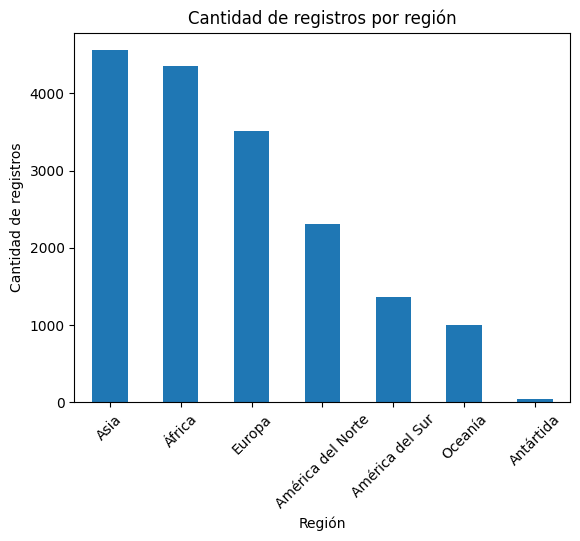

In [84]:
# Cantidad de registros por región
registros_region = df_eda["region"].value_counts()

registros_region.plot(kind="bar")

plt.title("Cantidad de registros por región")
plt.xlabel("Región")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

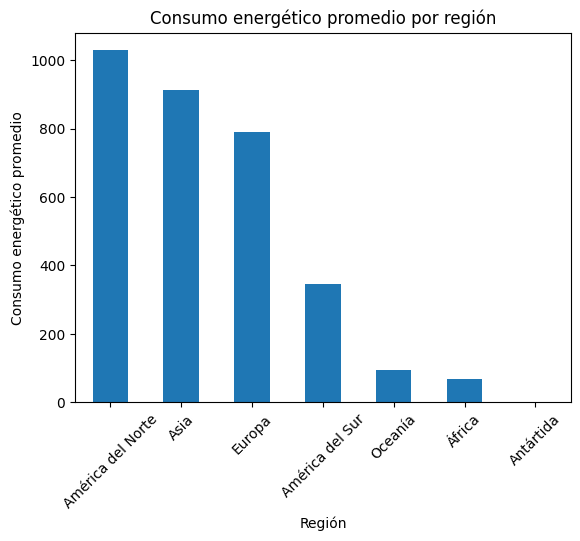

In [87]:
# Consumo energético promedio por región
consumo_region = (
    df_eda.groupby("region")["primary_energy_consumption"]
    .mean()
    .sort_values(ascending=False)
)

consumo_region.plot(kind="bar")

plt.title("Consumo energético promedio por región")
plt.xlabel("Región")
plt.ylabel("Consumo energético promedio")
plt.xticks(rotation=45)
plt.show()

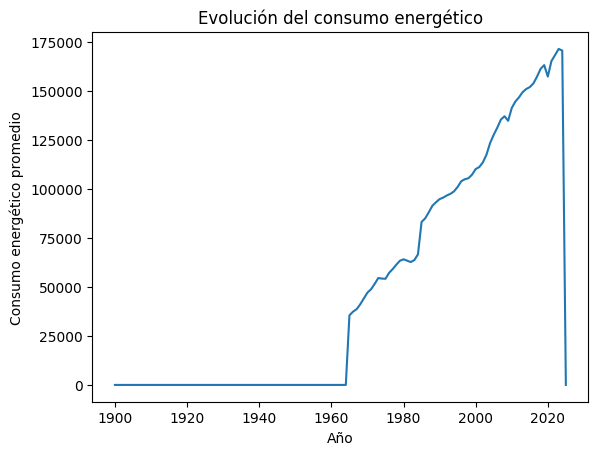

In [91]:
# Evolución del consumo energético
consumo_anual = (
    df_eda.groupby("year")["primary_energy_consumption"]
    .sum()
)

consumo_anual.plot(kind="line")

plt.title("Evolución del consumo energético")
plt.xlabel("Año")
plt.ylabel("Consumo energético promedio")
plt.show()

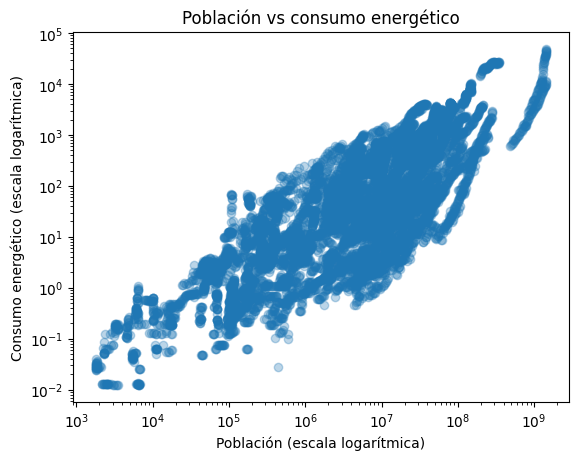

In [90]:
plt.scatter(
    df_eda["population"],
    df_eda["primary_energy_consumption"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title("Población vs consumo energético")
plt.xlabel("Población (escala logarítmica)")
plt.ylabel("Consumo energético (escala logarítmica)")
plt.show()

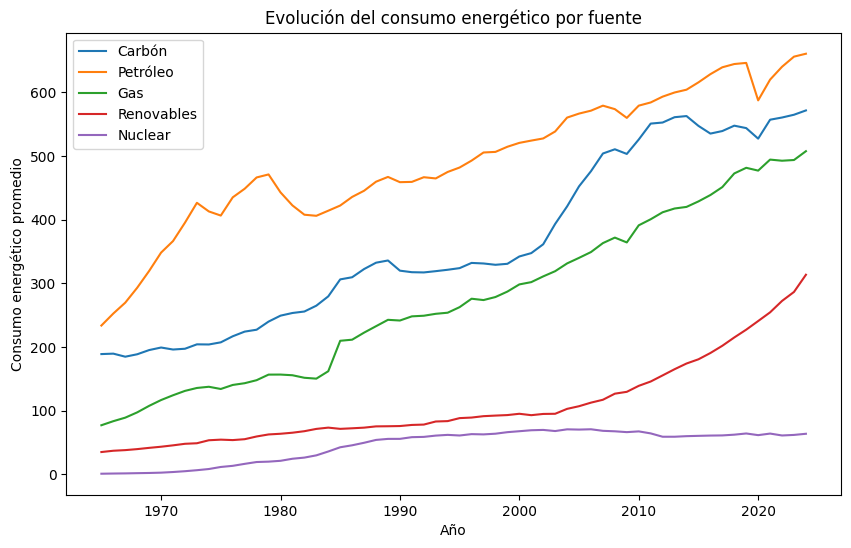

In [92]:
# Evolución del consumo energético por fuente
fuentes = [
    "coal_consumption",
    "oil_consumption",
    "gas_consumption",
    "renewables_consumption",
    "nuclear_consumption"
]

consumo_fuentes = df_eda.groupby("year")[fuentes].mean()

consumo_fuentes.plot(figsize=(10, 6))

plt.title("Evolución del consumo energético por fuente")
plt.xlabel("Año")
plt.ylabel("Consumo energético promedio")
plt.legend([
    "Carbón",
    "Petróleo",
    "Gas",
    "Renovables",
    "Nuclear"
])

plt.show()

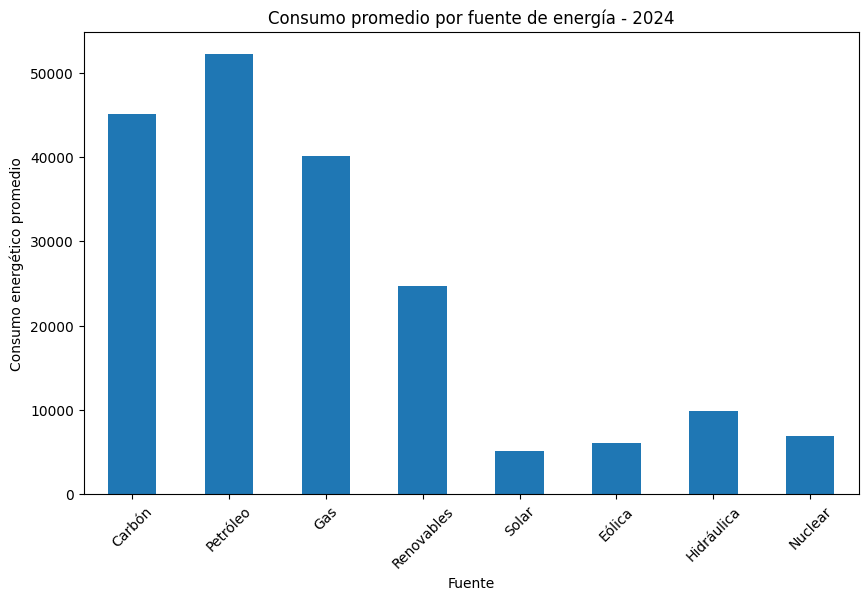

In [94]:
fuentes = [
    "coal_consumption",
    "oil_consumption",
    "gas_consumption",
    "renewables_consumption",
    "solar_consumption",
    "wind_consumption",
    "hydro_consumption",
    "nuclear_consumption"
]

consumo_2024 = df_eda[df_eda["year"] == 2024][fuentes].sum()

consumo_2024.plot(kind="bar", figsize=(10, 6))

plt.title("Consumo promedio por fuente de energía - 2024")
plt.xlabel("Fuente")
plt.ylabel("Consumo energético promedio")
plt.xticks(
    range(len(fuentes)),
    [
        "Carbón", "Petróleo", "Gas", "Renovables",
        "Solar", "Eólica", "Hidráulica", "Nuclear"
    ],
    rotation=45
)

plt.show()

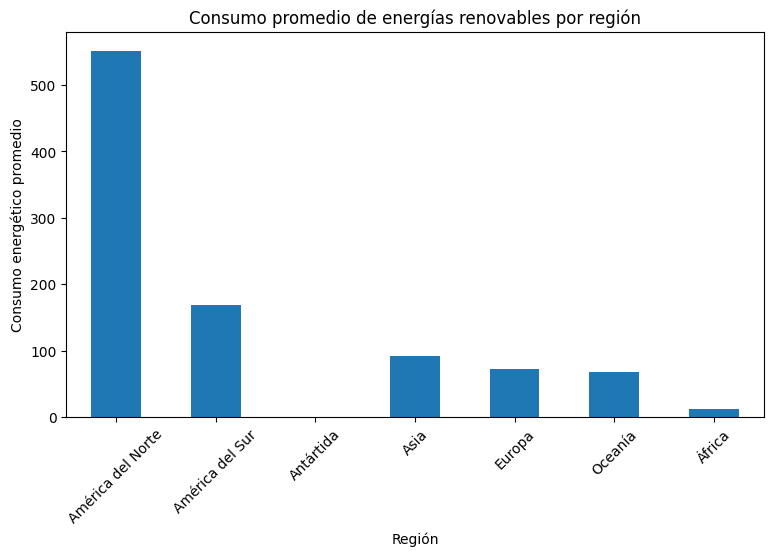

In [95]:
renovables_region = (
    df_eda.groupby("region")["renewables_consumption"]
    .mean()
)

renovables_region.plot(kind="bar", figsize=(9, 5))

plt.title("Consumo promedio de energías renovables por región")
plt.xlabel("Región")
plt.ylabel("Consumo energético promedio")
plt.xticks(rotation=45)

plt.show()

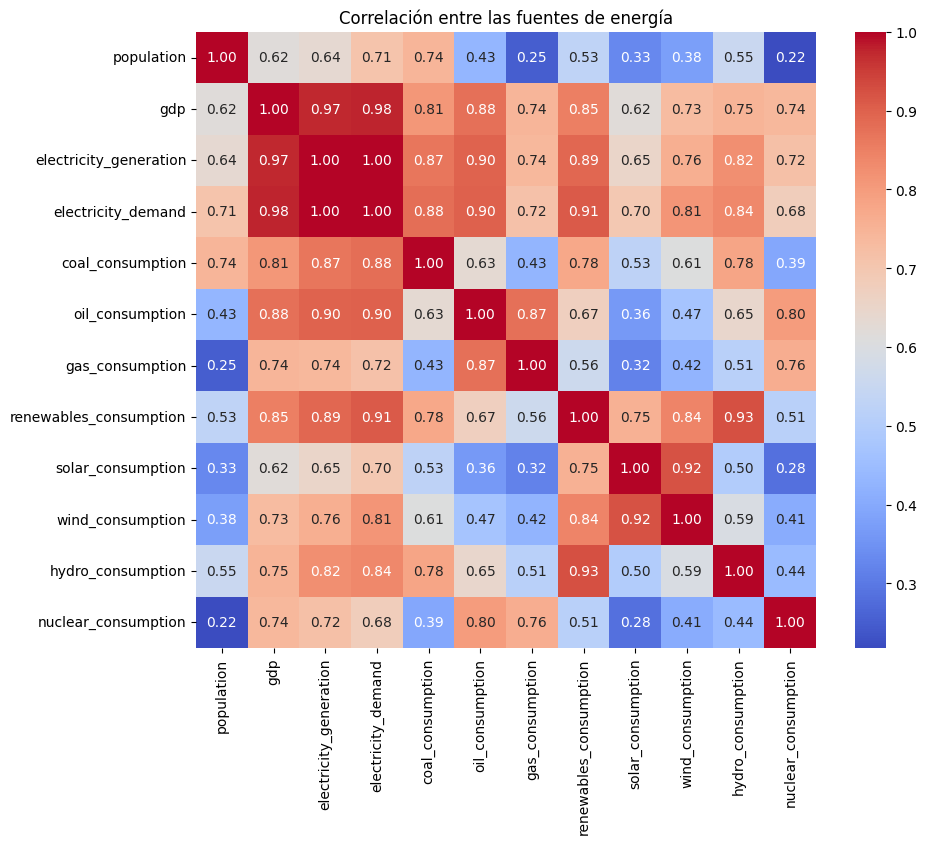

In [106]:
# Correlaciones entre fuentes de energía
fuentes_cor = [
    "population",
    "gdp",
    "electricity_generation",
    "electricity_demand",
    "coal_consumption",
    "oil_consumption",
    "gas_consumption",
    "renewables_consumption",
    "solar_consumption",
    "wind_consumption",
    "hydro_consumption",
    "nuclear_consumption"
]

correlacion = df_eda[fuentes_cor].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlación entre las fuentes de energía")
plt.show()

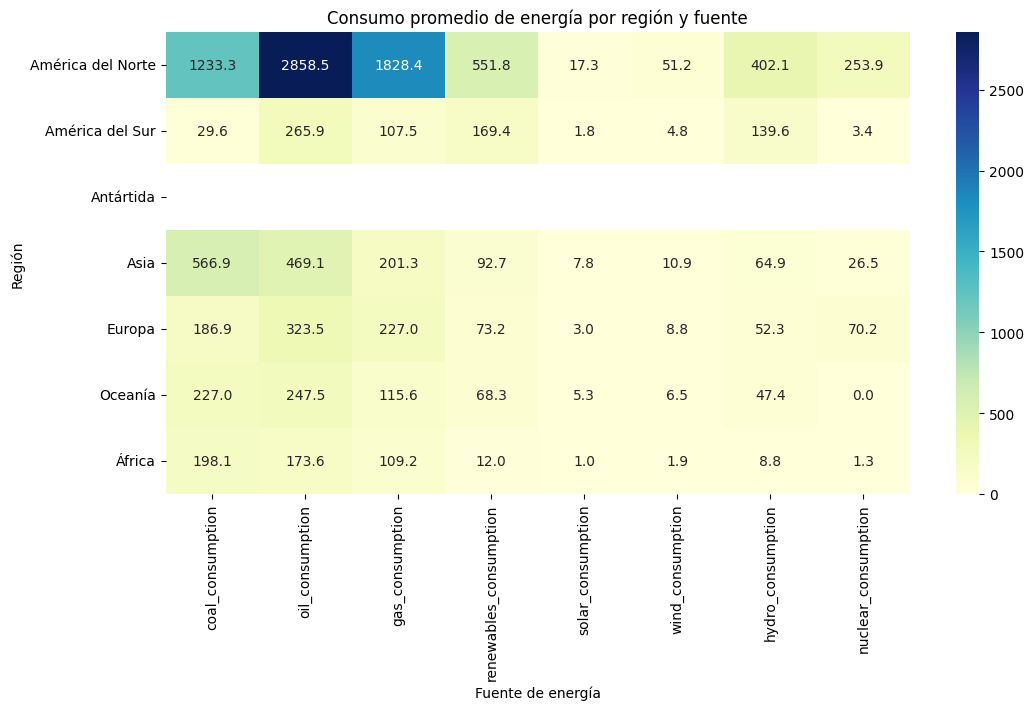

In [97]:
consumo_region = df_eda.groupby("region")[fuentes].mean()

plt.figure(figsize=(12, 6))

sns.heatmap(
    consumo_region,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Consumo promedio de energía por región y fuente")
plt.xlabel("Fuente de energía")
plt.ylabel("Región")

plt.show()